# Notebook 3: Classification with the scikit-learn Breast Cancer Dataset
*Author: Sara Speelman; 2026-03-15*

In this notebook, you will apply a full machine learning workflow to a **classification problem** using the breast cancer dataset from scikit-learn. You will use different models in the family of the decision tree:
- baseline model
- decision tree
- random forest
- XGBoost models

Furthermore, we will add **feature selection** to our workflow, and practise hyperparameter tuning some more.

Learning outcomes:
- create a correct train/val/test set for a classification problem
- training and evaluating a model for a **classification problem in a medical application**
- using scikit-learn's Pipeline for the model workflow, with **feature selection** and hyperparameter tuning

For this classification problem, we use the __[Breast Cancer Wisconsin (Diagnostic) dataset](https://scikit-learn.org/stable/datasets/toy_dataset.html#breast-cancer-dataset)__ from scikit-learn. It contains 569 samples, derived from digitized images of fine needle aspirates (FNA). Each sample includes 30 features describing cell nuclei characteristics, and a binary target indicating whether the tumor is malignant (0) or benign (1). 

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, roc_auc_score, roc_curve, f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import random

random_state = 42
random.seed(random_state)

In [2]:
# DEMO
# Load the breast cancer dataset, and create a DataFrame for the features and a Series for the target variable
data = load_breast_cancer(as_frame=True)

X = data.data
y = data.target

## 3. Global Data Inspection & Cleaning

- Inspect data types, missing values, and duplicates.
- Clean data as needed.
- Inspect class distribution/imbalance.

In [3]:
# EXERCISE
# Print the description of the dataset, using .DESCR
print(data.DESCR)

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [4]:
# EXERCISE
# Print the shape of X and y
print('Shape of X:', X.shape)
print('Shape of y:', y.shape)

Shape of X: (569, 30)
Shape of y: (569,)


In [5]:
# EXERCISE
# Show the first few rows of the features dataset
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [6]:
# EXERCISE
# Show the first few rows of the target variable
y.head()

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

In [7]:
# EXERCISE
# Check Dtype of the features
print("\nDtypes summary:")
print(X.dtypes.value_counts())


Dtypes summary:
float64    30
Name: count, dtype: int64


In [8]:
# EXERCISE
# Check whether there are any NaNs over the whole dataset (same as isnull)
print("\nAny NaNs overall:", X.isna().any().any())


Any NaNs overall: False


In [9]:
# EXERCISE
# Check for duplicate columns
dup_cols = X.columns[X.columns.duplicated()]
print("\nDuplicate column names:", list(dup_cols))

# Check for duplicate rows
dup_rows = X.duplicated()
print("\nNumber of duplicated rows:", dup_rows.sum())


Duplicate column names: []

Number of duplicated rows: 0


In [10]:
# EXERCISE
# Check whether there is class imbalance
print('Target Distribution (proportion)')
print((y.value_counts(normalize=True) * 100).round(2))

Target Distribution (proportion)
target
1    62.74
0    37.26
Name: proportion, dtype: float64


Let's not forget the basics: do we understand our problem? What do the class labels mean? Is malignant a zero or a one?  
The description mentions there are more benign than malignant cases, so benign must be class 1. We can also get this information directly from the data object

In [11]:
# DEMO
# Print the target class names
print(data.target_names)

['malignant' 'benign']


## 4. Train/Validation/Test Split

We will split our dataset in a training set (crossvalidation for hyperparam tuning), a validation set (model selection) and a test set (performance estimate on unseen data).  
Since we have mild class imbalance, how can we ensure our different sets are representative for our data distribution? Have a look at the __[documentation of train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)__ to check which parameter can help you with this.

In [12]:
# EXERCISE
# Split data into training and testing sets using stratified train_test_split
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=random_state)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=random_state) # 0.25 x 0.8 = 0.2

How do our data splits look now? A plot would help to get more intuition:

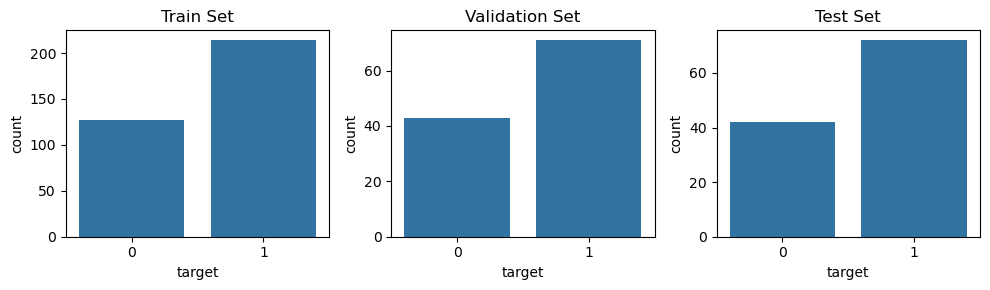

In [13]:
# DEMO
# Plot bar plots of the target variable distribution in the train, validation, and test sets
# HINT:You could use seaborn's countplot 
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
sns.countplot(x=y_train, ax=axes[0])
axes[0].set_title('Train Set')
sns.countplot(x=y_val, ax=axes[1])
axes[1].set_title('Validation Set')
sns.countplot(x=y_test, ax=axes[2])
axes[2].set_title('Test Set')
plt.tight_layout()
plt.show()

## 5. Exploratory Data Analysis (EDA)

### 5.1 Summary Statistics

In [14]:
# EXERCISE
# Summary statistics of the features in the training dataset
X_train.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000,...,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000
mean,14.030343,19.183754,91.409179,646.441935,0.096563,0.106437,0.092774,0.049489,0.181108,0.063241,...,16.163044,25.499531,106.713754,870.835777,0.132554,0.261413,0.284138,0.115346,0.291730,0.084646
std,3.550771,4.528923,24.538890,352.949179,0.013524,0.054265,0.083839,0.039768,0.028106,0.007367,...,4.894558,6.504884,34.222644,574.143700,0.022703,0.166199,0.223161,0.068145,0.065173,0.018734
min,6.981000,9.710000,43.790000,143.500000,0.062510,0.019380,0.000000,0.000000,0.116700,0.050240,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.160300,0.055250
25%,11.600000,15.860000,74.340000,412.600000,0.086750,0.066010,0.027830,0.019690,0.162000,0.058590,...,12.970000,20.790000,83.670000,509.600000,0.115700,0.148200,0.106000,0.062270,0.252300,0.072420
50%,13.170000,18.750000,85.840000,536.900000,0.096760,0.095090,0.061950,0.032640,0.178400,0.061770,...,14.850000,25.090000,97.650000,680.600000,0.131600,0.215600,0.243400,0.096530,0.283300,0.080190
75%,15.490000,21.680000,102.400000,744.900000,0.105400,0.132800,0.142500,0.077620,0.195300,0.066690,...,17.980000,29.410000,122.400000,985.500000,0.146000,0.342000,0.397700,0.165400,0.319800,0.092230
max,28.110000,39.280000,188.500000,2499.000000,0.142500,0.345400,0.426400,0.191300,0.304000,0.097440,...,33.130000,49.540000,229.300000,3432.000000,0.218400,1.058000,1.252000,0.291000,0.663800,0.207500


What can you conclude about the feature scales?

### 5.2 Data Visualization

It's important to vizualize our data to get a better understanding of the dataset we are working with. For a classification problem, a number of things can provide more insight, e.g.
- scatter plots of feature pairs
- Violin plots, histograms and box plots to inspect distributions and outliers

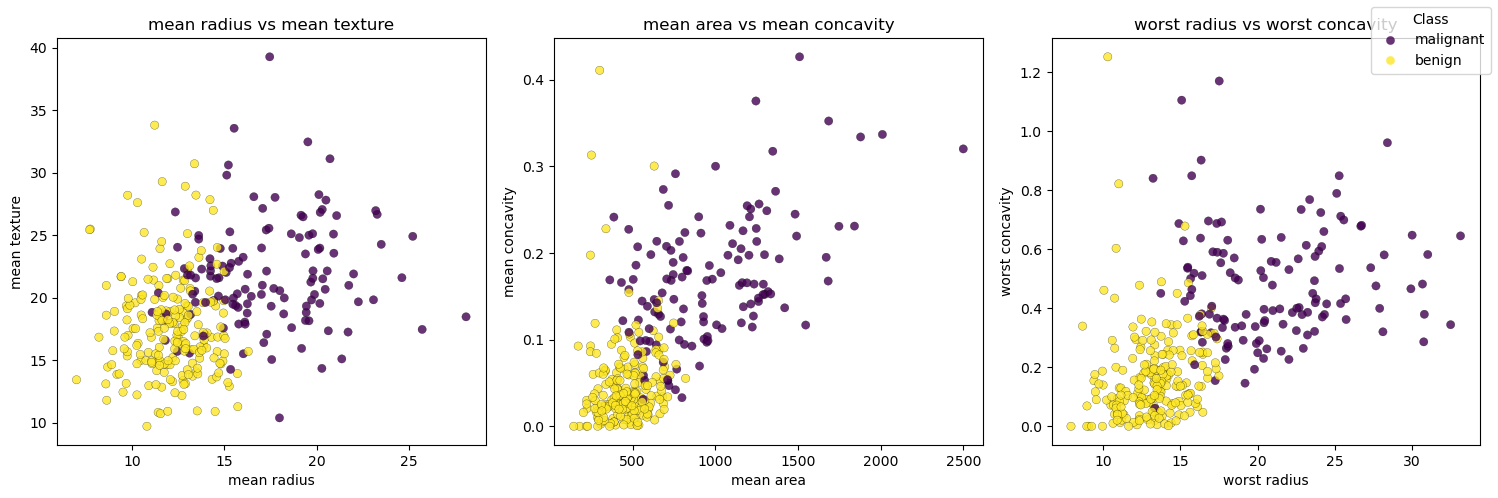

In [15]:
# DEMO
# Pick feature pairs and plot them as scatter plots with points colored by class
feature_pairs = [
    ("mean radius", "mean texture"),
    ("mean area", "mean concavity"),
    ("worst radius", "worst concavity")
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (feature1, feature2) in enumerate(feature_pairs):
    sc = axes[i].scatter(
        X_train[feature1],
        X_train[feature2],
        c=y_train,
        cmap="viridis",
        alpha=0.8,
        edgecolors="k",
        linewidths=0.2
    )
    axes[i].set_xlabel(feature1)
    axes[i].set_ylabel(feature2)
    axes[i].set_title(f"{feature1} vs {feature2}")

# Shared legend (0 = malignant, 1 = benign)
handles, _ = sc.legend_elements()
fig.legend(handles, data.target_names, title="Class", loc="upper right")

plt.tight_layout()
plt.show()

Do you see a rough line that could seperate the classes?  
Is there an overlap region? Those points will be hard for the classifier.

Next, we'll check whether we have outliers. We can see the ranges of the features in the summary statistics. Let's make plots of some features with large ranges.  

A **violin plot** shows the distribution of a variable by combining a boxplot with a smoothed density shape. The wider parts of the violin indicate where more data points are concentrated, while the thinner parts show where values are less common.

In [16]:
# DEMO
# Compute feature ranges from X_train.describe() and show the top 5 features with the largest ranges
desc = X_train.describe()
feature_ranges = desc.loc["max"] - desc.loc["min"]

top_5_ranges = feature_ranges.sort_values(ascending=False).head(5)
print(top_5_ranges)

worst area         3246.800
mean area          2355.500
area error          518.798
worst perimeter     178.890
mean perimeter      144.710
dtype: float64


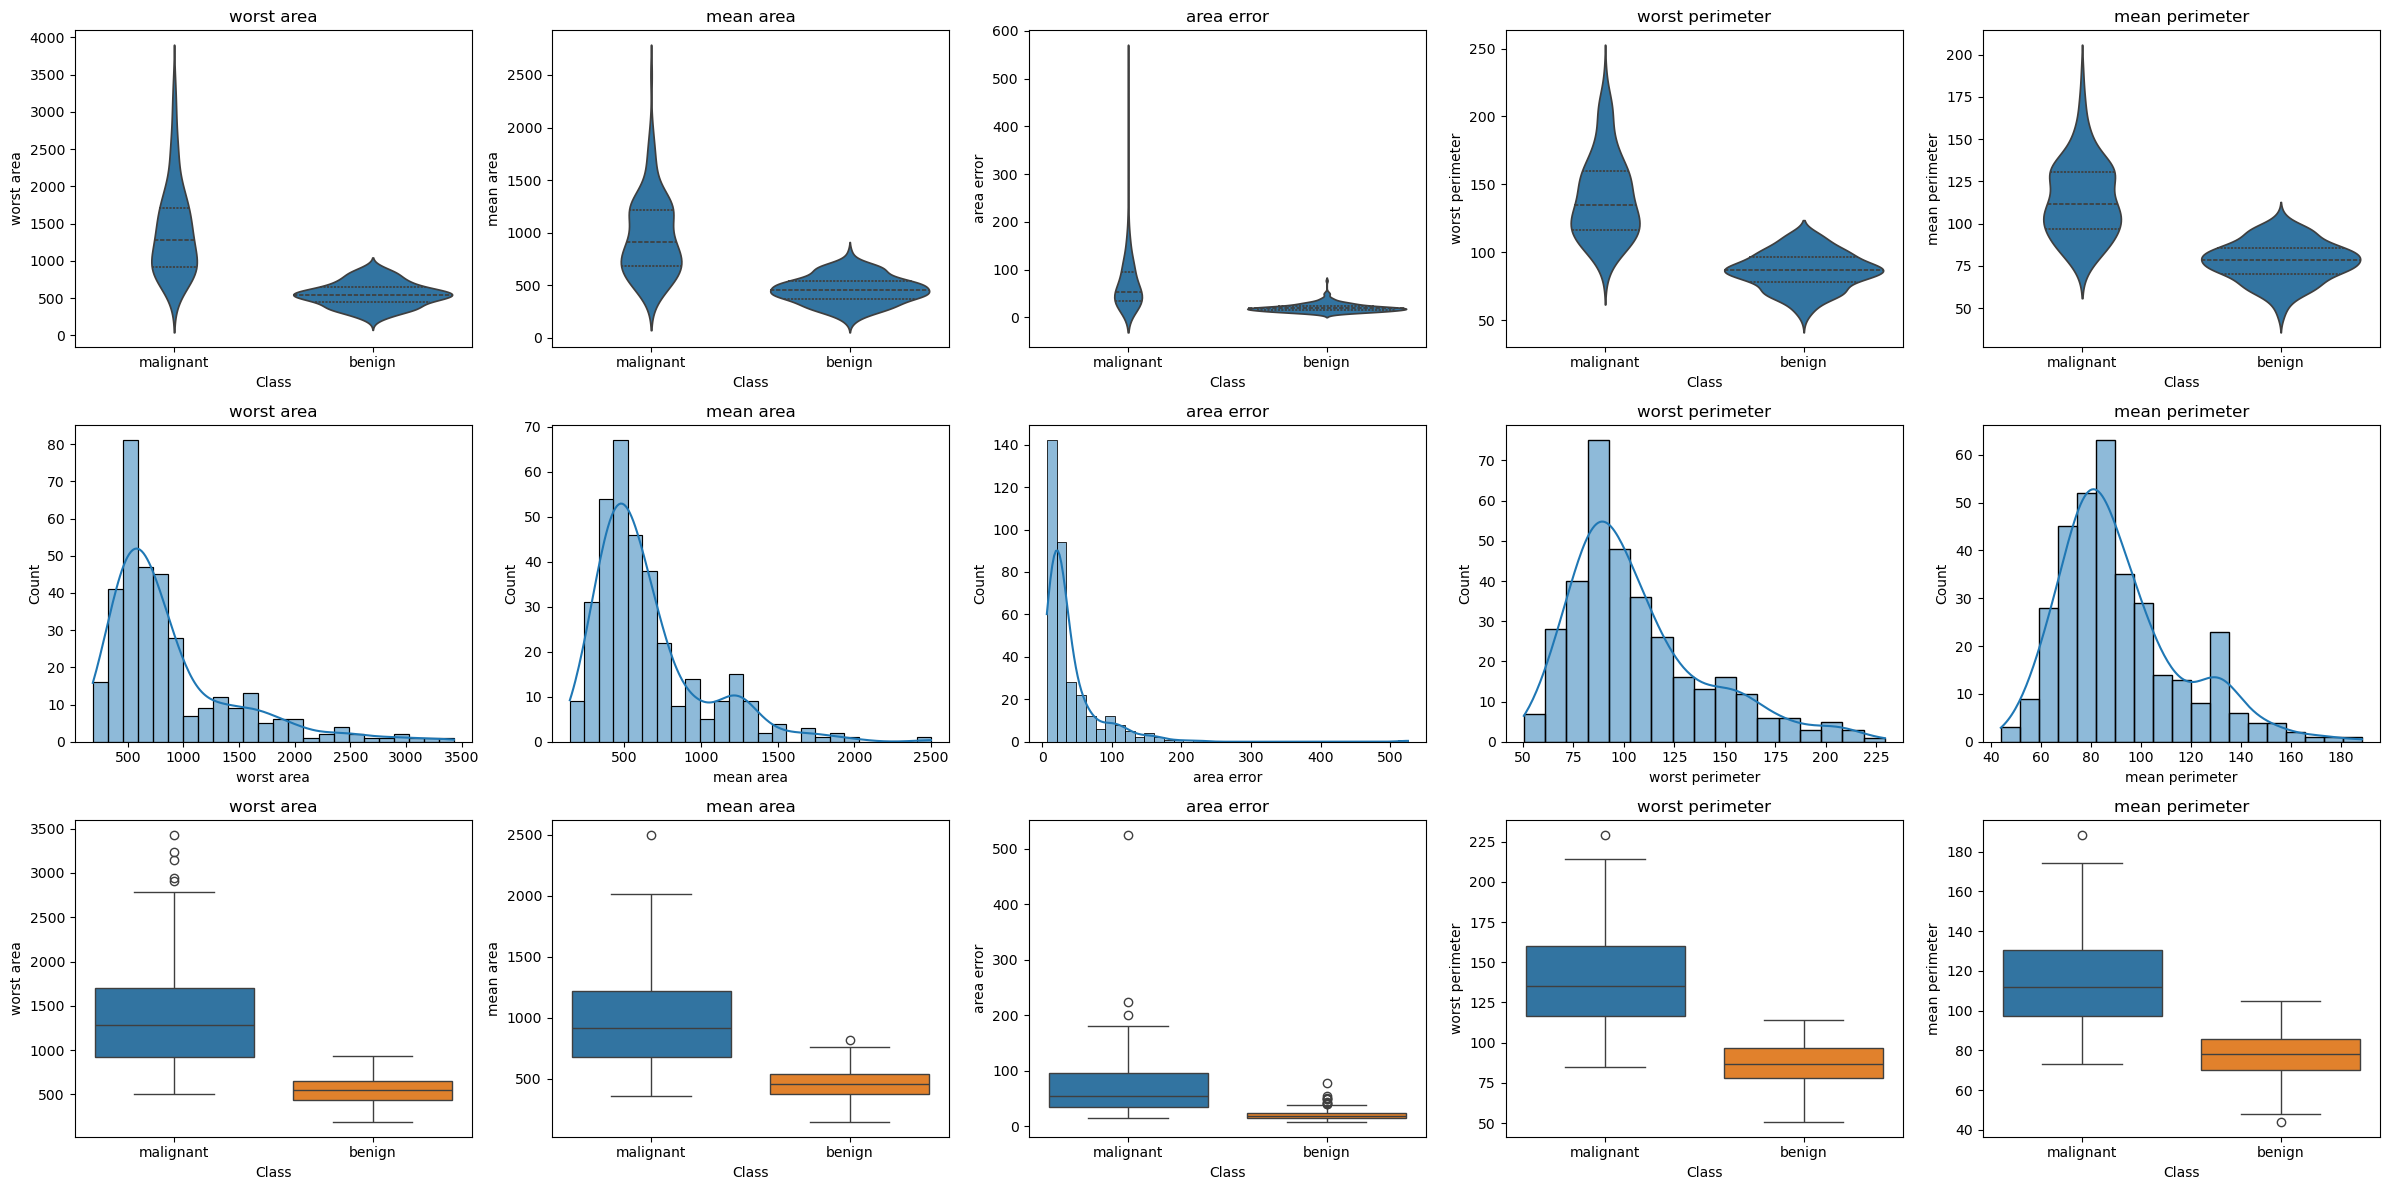

In [17]:
# DEMO
# Violin plots, Histograms + KDE, and Box plots for the 5 features with the largest ranges

top_features = top_5_ranges.index.tolist()

fig, axes = plt.subplots(3, 5, figsize=(24, 12))

# Row 1: Violin plots split by class
for i, feature in enumerate(top_features):
    sns.violinplot(
        data=X_train.assign(target=y_train),
        x="target",
        y=feature,
        ax=axes[0, i],
        inner="quartile"
    )
    axes[0, i].set_title(feature)
    axes[0, i].set_xlabel("Class")
    axes[0, i].set_xticks([0, 1])
    axes[0, i].set_xticklabels(data.target_names)

# Row 2: Histograms + KDE
for i, feature in enumerate(top_features):
    sns.histplot(
        X_train[feature],
        kde=True,
        ax=axes[1, i]
    )
    axes[1, i].set_title(feature)
    axes[1, i].set_xlabel(feature)

# Row 3: Box plots split by class
for i, feature in enumerate(top_features):
    sns.boxplot(
        data=X_train.assign(target=y_train),
        x="target",
        y=feature,
        ax=axes[2, i],
        hue="target",
        legend=False
    )
    axes[2, i].set_title(feature)
    axes[2, i].set_xlabel("Class")
    axes[2, i].set_xticks([0, 1])
    axes[2, i].set_xticklabels(data.target_names)

plt.tight_layout()
plt.show()


What do these box plots tell us about feature distributions and outliers? Do we have to scale our data here?  
Have a look at some possible scalers:

- __[StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)__
- __[RobustScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.RobustScaler.html)__
- __[MinMaxScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html)__  

A common approach is to **standardize** each feature with `StandardScaler`:

- centering it: subtract the mean
- scaling it: divide by the standard deviation

This gives features with approximately mean 0 and variance 1.
If your data contains many outliers, scaling using the mean and variance of the data is likely to not work very well. In these cases, you can use RobustScaler as a drop-in replacement instead. It uses more robust estimates for the center and range of your data. __[source](https://scikit-learn.org/stable/modules/preprocessing.html#preprocessing-scaler)__

We invite you to have a look at a __[comparison of the effect of different scalers on data with outliers](https://scikit-learn.org/stable/auto_examples/preprocessing/plot_all_scaling.html#plot-all-scaling-standard-scaler-section)__

### 5.3 Correlation matrix

Make a correlation matrix of our training set features to capture linear relationships. Why is this relevant?  
Make sure you are familiar with __[multicollinearity](https://www.geeksforgeeks.org/machine-learning/multicollinearity-in-data/)__ and related issues.

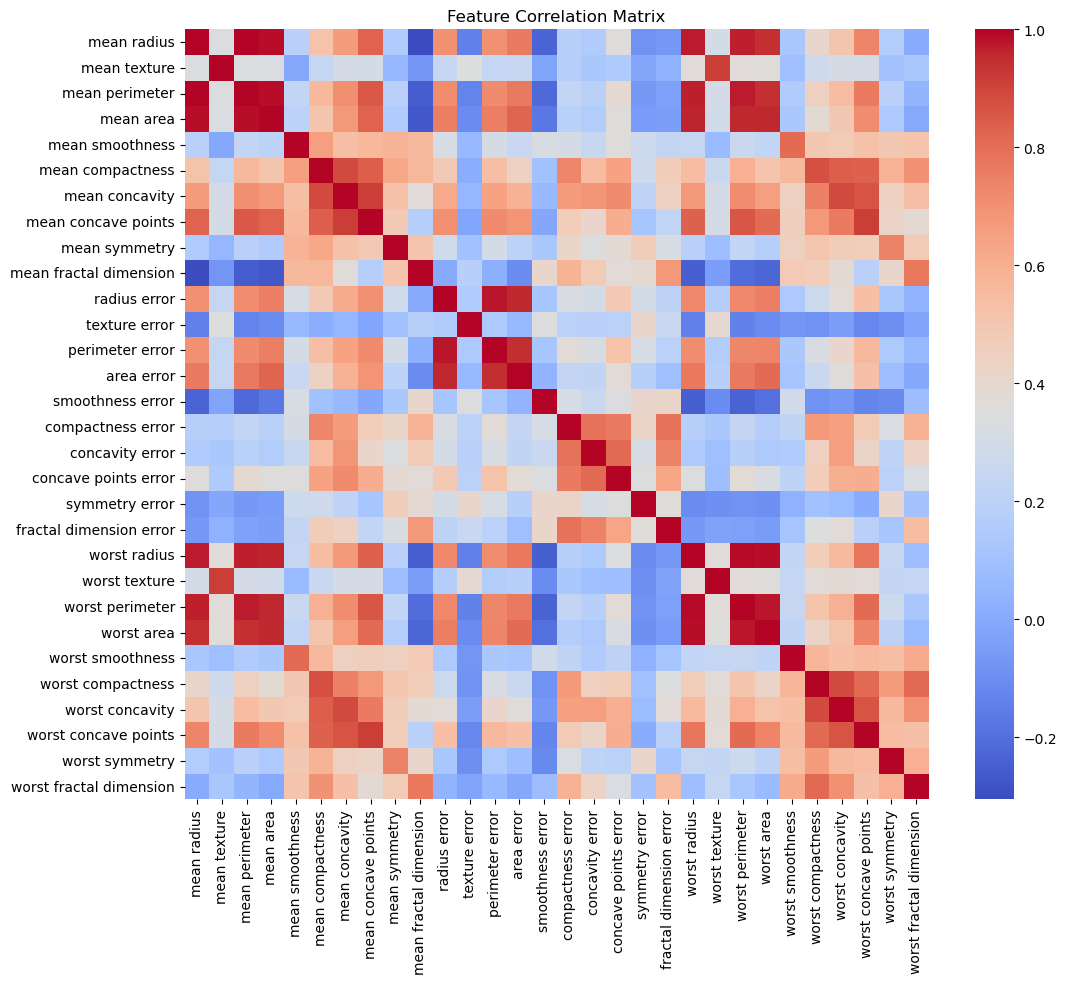

In [18]:
# EXERCISE
# Plot a correlation matrix of the training features
corr = X_train.corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

What do we learn from our correlation matrix? Would we feed all our features to the model?

## 6. Feature Selection
In this section, we will explore two different feature selection methods: **SelectKBest** and **Feature Importance**. We invite you to explore other methods yourself, for example, don't hesitate to delve into __[Recursive feature elimination (RFE)](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.RFE.html)__, or dimensionality reduction techniques such as **PCA**.

As as example, we will select the best 10 features with these methods. This section is mainly to help you get a feeling of these methods, but won't actually be used by our model. Instead, we will add feature selection (with SelectKBest) in our Pipeline below. 

### 6.1 SelectKBest demo
**SelectKBest** selects the top k features that have the strongest relationship with the target variable, based on a statistical test. We will use mutual information here, applying the theory you have seen in class.

Read the docs: https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectKBest.html 

In [19]:
# DEMO
# Select the top 10 features using mutual information
from sklearn.feature_selection import SelectKBest, mutual_info_classif
selector = SelectKBest(score_func=mutual_info_classif, k=10)
selector.fit(X_train, y_train)
selected_features = X_train.columns[selector.get_support()]
print('Selected features (SelectKBest): \n', selected_features.tolist())

Selected features (SelectKBest): 
 ['mean radius', 'mean perimeter', 'mean area', 'mean concavity', 'mean concave points', 'area error', 'worst radius', 'worst perimeter', 'worst area', 'worst concave points']


### 6.2 Feature Importances demo
Tree-based models like Random Forests can provide an estimate of feature importance, which reflects how useful each feature was in the construction of the model. We can use the **feature_importances_** attribute of the **RandomForestClassifier** object of scikit-learn. In Random Forests, impurity-based feature importance measures how much a feature helps reduce node impurity during tree construction. 
Below, we fit a Random Forest and visualize the top features. 

Have a look at **permutation importance** on your own. This one measures how much model performance decreases when the values of that feature are randomly shuffled after training.

Top 10 features by importance:
1. worst concave points (0.1818)
2. worst area (0.1424)
3. mean concave points (0.0967)
4. worst perimeter (0.0802)
5. mean concavity (0.0714)
6. mean area (0.0514)
7. mean perimeter (0.0514)
8. worst radius (0.0499)
9. mean radius (0.0411)
10. area error (0.0343)


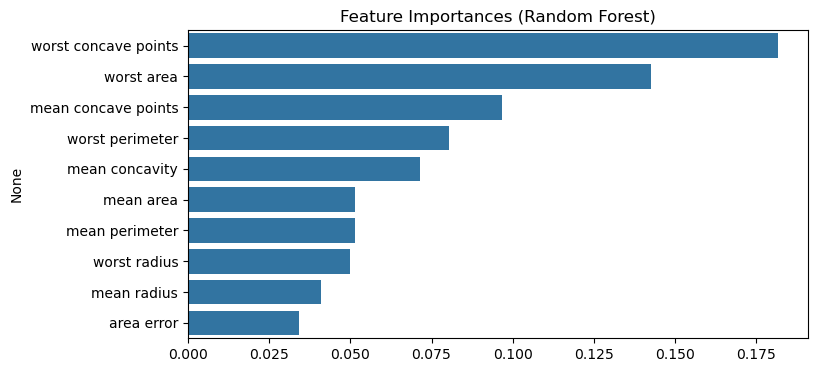

In [20]:
# DEMO
# Feature importance using Random Forest
from sklearn.ensemble import RandomForestClassifier

# Create and fit the model
rf = RandomForestClassifier(random_state=random_state)
rf.fit(X_train, y_train)

# Retrieve feature importances thourgh the feature_importances_ attribute
importances = rf.feature_importances_

# Print the top 10 features
indices = np.argsort(importances)[::-1]
print('Top 10 features by importance:')
for f in range(10):
    print(f"{f + 1}. {X_train.columns[indices[f]]} ({importances[indices[f]]:.4f})")

# Plot feature importances
plt.figure(figsize=(8,4))
plt.title('Feature Importances (Random Forest)')
sns.barplot(x=importances[indices[:10]], y=X_train.columns[indices[:10]])
plt.show()

## 7. Model Training
In this section, we will train a Random Forest (7.1) and an XGBoost classifier (7.2), with SelectKBest for feature selection. To help you get started, read the example of the decision tree pipeline.

In [21]:
# DEMO
# Decision Tree pipeline with GridSearchCV
# Create a pipeline with scaling, feature selection, and classifier
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(score_func=mutual_info_classif, k=10)),
    ('clf', DecisionTreeClassifier(random_state=random_state))
])
# Define parameter grid for GridSearchCV
param_grid = {
    'clf__max_depth': [3, 5, 7, None],
    'clf__min_samples_split': [2, 5, 10]
}
# Perform Grid Search with cross-validation
grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

# Print best parameters and best cross-validation score
print('Best parameters:', grid.best_params_)
print('Best cross-val accuracy:', round(grid.best_score_, 4))

Best parameters: {'clf__max_depth': 3, 'clf__min_samples_split': 2}
Best cross-val accuracy: 0.9414


Set `n_jobs=-1` to use all available CPU cores to run the search in parallel. Otherwise `GridSearchCV` can take a long time to run, for larger parameter grids.

(How) could you improve the cross validation strategy in this demo?

### 7.0 Baseline model
As a dummy baseline to compare or model performance to, we use a majority classifier.

In [22]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

# Baseline: majority classifier (predicts most frequent class)

majority_clf = DummyClassifier(strategy="most_frequent")
majority_clf.fit(X_train, y_train)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None


### 7.1 Random Forest Classifier with RandomizedSearchCV

We will use __[RandomizedSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html)__ here, which samples a fixed number (n_iter, 10 by default) of parameter settings from the specified distributions, making it more efficient for larger search spaces. In other words: `GridSearchCV` is more exhaustive, while `RandomizedSearchCV` is usually more efficient.  
Beware, with RandomizedSearchCV we are **sampling from a parameter distribution** instead of looping through all parameters in a parameter grid. We must thus define parameter distributions here.

A `RandomForestClassifier` combines many decision trees and makes a final prediction based on all of them rather than relying on a single tree. This usually makes it more stable and less prone to overfitting than one decision tree alone. Read the __[documentation of the RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)__ to see which important hyperparameters we have to tune. Think about what parameter distributions would make sense.

In [23]:
# EXERCISE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Create a Random Forest pipeline with RandomizedSearchCV
rf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(score_func=mutual_info_classif, k=10)),
    ('clf', RandomForestClassifier(random_state=random_state))
])
# Define parameter distribution for RandomizedSearchCV
param_dist_rf = {
    'clf__n_estimators': randint(50, 200),
    'clf__max_depth': [3, 5, 7, None],
    'clf__min_samples_split': randint(2, 11),
    'clf__min_samples_leaf': [1, 2, 4]
}
# Perform Randomized Search with cross-validation
rf_random_search = RandomizedSearchCV(rf_pipe, 
                                      param_distributions=param_dist_rf, 
                                      n_iter=40, 
                                      cv=5, 
                                      scoring='accuracy', 
                                      random_state=random_state, 
                                      n_jobs=-1)
rf_random_search.fit(X_train, y_train)

# Print best parameters and best cross-validation score
print('Best parameters (RF):', rf_random_search.best_params_)
print('Best cross-val accuracy (RF):', round(rf_random_search.best_score_, 4))

Best parameters (RF): {'clf__max_depth': 7, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 4, 'clf__n_estimators': 100}
Best cross-val accuracy (RF): 0.9502


(How) could you improve the cross validation strategy used in this solution?

**Note**: I randomly chose k=10 as amount of features. But we could optimise this as well. Try yourself whether you can adapt the code cell above to make k a parameter in our in our parameter distribution as well.

### 7.2 XGBoost Classifier with RandomizedSearchCV
**XGBClassifier** is an ML model that uses 'eXtreme Gradient Boosting'. It sequentially builds multiple decision trees, with each tree correcting the errors of the previous ones. The final result is a combination of the result of the individual trees. 

Read the __[documentation of XGBoost](https://xgboost.readthedocs.io/en/stable/parameter.html)__ to understand which hyperparameters we should tune. Or the __[GeeksforGeeks page](https://www.geeksforgeeks.org/machine-learning/xgbclassifier/)__, as it's an easier introduction.

In [24]:
# EXERCISE
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from scipy.stats import randint, uniform, loguniform

# Create an XGBoost pipeline
xgb_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(score_func=mutual_info_classif, k=10)),
    ('clf', XGBClassifier(eval_metric='logloss', random_state=random_state))
])

param_dist_xgb = {
    'clf__n_estimators': randint(50, 200), # random integer for discrete variables
    'clf__max_depth': randint(3, 8), # random integer for discrete variables
    'clf__learning_rate': loguniform(0.01, 0.2), # use loguniform for learning rate as it spans several orders of magnitude
    "clf__subsample": uniform(0.4, 0.6) # uniform distribution
}

In [25]:
# EXERCISE
# use RandomizedSearchCV to find the best hyperparameters for XGBClassifier (with our defined param_dist)
xgb_pipe_random_search = RandomizedSearchCV(xgb_pipe, 
                                            param_distributions=param_dist_xgb, 
                                            n_iter=40, 
                                            cv=5, 
                                            scoring='accuracy', 
                                            n_jobs=-1, 
                                            random_state=random_state)
# Fit the RandomizedSearchCV to the training data
xgb_pipe_random_search.fit(X_train, y_train)

# Print best parameters and best cross-validation score
print('Best parameters (XGB):', xgb_pipe_random_search.best_params_)
print('Best cross-val accuracy (XGB):', round(xgb_pipe_random_search.best_score_, 4))

Best parameters (XGB): {'clf__learning_rate': np.float64(0.09381793717496219), 'clf__max_depth': 7, 'clf__n_estimators': 73, 'clf__subsample': np.float64(0.6140519960161536)}
Best cross-val accuracy (XGB): 0.956


(How) could you improve the cross validation strategy used in this solution?

## 8. Model selection
We will compare the performance of our 2 tree based models on the validation set, and choose the one that performs best.

In [26]:
# DEMO
# Compare validation accuracy of RF (random search) and XGB (random search)
# Select the best_estimator (the refit model on the whole training set) from each model + hyperparameter tuning method
best_rf = rf_random_search.best_estimator_
best_xgb_rand = xgb_pipe_random_search.best_estimator_

# Predict on validation set
y_val_dummy = majority_clf.predict(X_val)
y_val_pred_rf = best_rf.predict(X_val)
y_val_pred_xgb_rand = best_xgb_rand.predict(X_val)

# Compare validation accuracy of RF (random search), XGB (random search), and XGB (grid search)
# Use accuracy_score from sklearn.metrics to compute validation accuracies
acc_dummy = accuracy_score(y_val, y_val_dummy)
acc_rf = accuracy_score(y_val, y_val_pred_rf)
acc_xgb_rand = accuracy_score(y_val, y_val_pred_xgb_rand)

# Print the accuracy scores
print('Validation Accuracy (Dummy):', round(acc_dummy, 4))
print('Validation Accuracy (RF):', round(acc_rf, 4))
print('Validation Accuracy (XGB):', round(acc_xgb_rand, 4))

# Select the best model based on validation accuracy
if acc_rf > acc_xgb_rand:
    best_model = best_rf
    print("Best model: Random Forest")
else:
    best_model = best_xgb_rand
    print("Best model: XGBoost")

Validation Accuracy (Dummy): 0.6228
Validation Accuracy (RF): 0.9298
Validation Accuracy (XGB): 0.9386
Best model: XGBoost


In [27]:
# EXERCISE
# Select the model with the highest validation accuracy
best_model = best_xgb_rand 

## 9. Model Evaluation
Evaluate the performance of the model on unseen data. What is a suitable **performance metric** for this problem? Should we have used another performance metric in our cross-validation?   
Familiarize yourself with the following performance metrics:

- __[accuracy](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html)__: fraction of correct predictions
- __[precision](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html)__: **tp / (tp + fp)**: ability of a classifier not to label a negative sample as positive
- __[recall](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html)__: **tp / (tp + fn)**: ability of the classifier to find all the positive samples
- __[F1 score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html)__: **(2x tp)/ (2 x tp + fp + fn)**: a harmonic mean of the precision and recall, where an F1 score reaches its best value at 1 and worst score at 0. The relative contribution of precision and recall to the F1 score are equal.

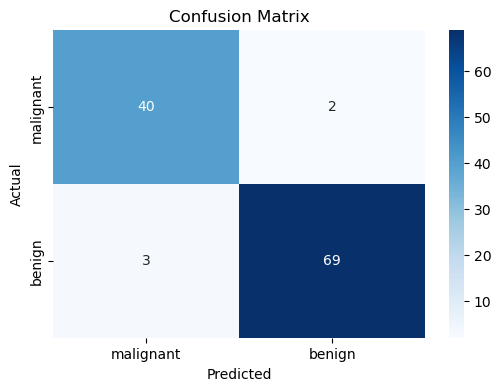

Test accuracy: 0.96
Precision: 0.93
Recall: 0.95
F1-score: 0.94
Classification Report:
              precision    recall  f1-score   support

   malignant       0.93      0.95      0.94        42
      benign       0.97      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114

AUC-ROC: 0.9888


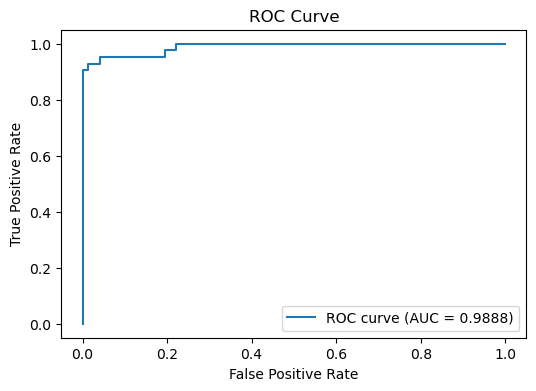

In [28]:
# DEMO
# Evaluate best model on test set
y_pred = best_model.predict(X_test)

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Print evaluation metrics
# Include accuracy, confusion matrix, precision, recall
print(f"Test accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision: {precision_score(y_test, y_pred, pos_label=0):.2f}")
print(f"Recall: {recall_score(y_test, y_pred, pos_label=0):.2f}")
print(f"F1-score: {f1_score(y_test, y_pred, pos_label=0):.2f}")

# Print classification report
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=data.target_names))

# Calculate AUC-ROC and plot ROC curve
y_proba = best_model.predict_proba(X_test)[:,0]
fpr, tpr, thresholds = roc_curve(y_test, y_proba, pos_label=0)
auc_roc = 1- roc_auc_score(y_test, y_proba)
print('AUC-ROC:', round(auc_roc, 4))

# Plot AUC-ROC
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc_roc:.4f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

What can you conclude about the scores? What should you do when you have such high performances? 

What does the ROC curve tell us? When is this metric useful? Is is suitable for our current medical application? Do we care evenly about false positives and false negatives?

**Disclaimer**: GenAI was used when creating this Notebook.